In [17]:
# Setup

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ID = "fyxical-poc"
DATASET    = "fyxical_poc"
client     = bigquery.Client(project=PROJECT_ID)

patients = client.query(f"""
    SELECT p.*, pw.recommended_pathway
    FROM `{PROJECT_ID}.{DATASET}.patient_intake` p
    JOIN `{PROJECT_ID}.{DATASET}.patient_pathways` pw USING (patient_id)
""").to_dataframe()

print(f"Patients loaded: {len(patients)}")

Patients loaded: 500


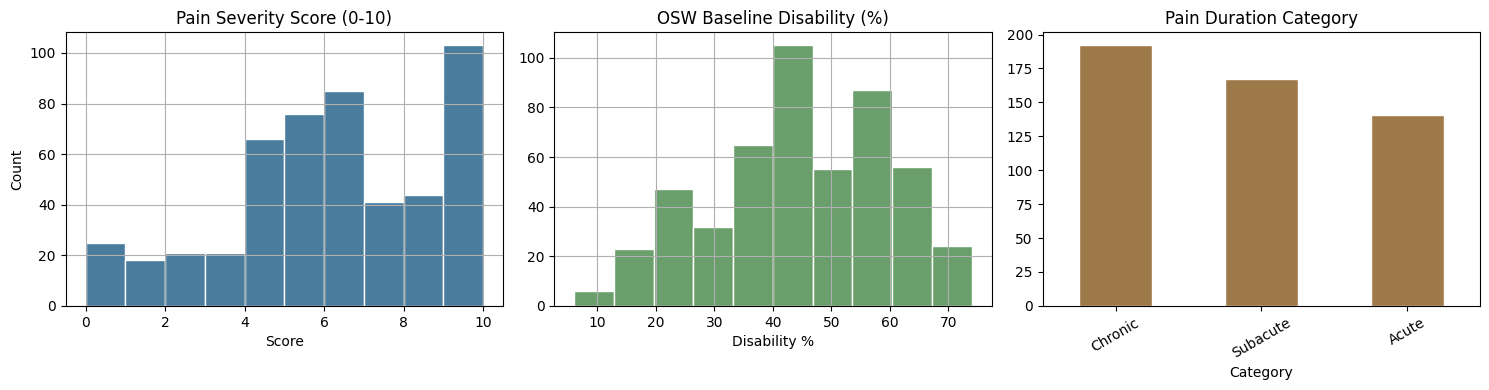

In [18]:
# Clinical Variable Distributions

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

patients["pain_severity_score_0_10"].hist(
    ax=axes[0], bins=10, color="#4a7c9e", edgecolor="white"
)
axes[0].set_title("Pain Severity Score (0-10)")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Count")

patients["osw_baseline_percent_disability"].hist(
    ax=axes[1], bins=10, color="#6a9e6a", edgecolor="white"
)
axes[1].set_title("OSW Baseline Disability (%)")
axes[1].set_xlabel("Disability %")

patients["pain_duration_category"].value_counts().plot(
    kind="bar", ax=axes[2], color="#9e7a4a", edgecolor="white"
)
axes[2].set_title("Pain Duration Category")
axes[2].set_xlabel("Category")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("clinical_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

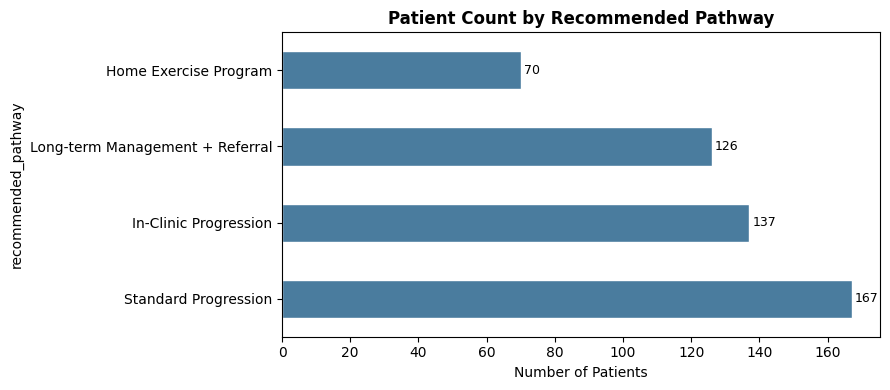

In [19]:
# Pathway Distribution

pathway_counts = patients["recommended_pathway"].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
pathway_counts.plot(kind="barh", ax=ax, color="#4a7c9e", edgecolor="white")
ax.set_title("Patient Count by Recommended Pathway", fontweight="bold")
ax.set_xlabel("Number of Patients")
for i, v in enumerate(pathway_counts):
    ax.text(v + 1, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.savefig("pathway_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
# Demographic Variable Rationale

rationale = """
Demographic Variables — Purpose and Rationale
---------------------------------------------
Demographic variables (sex, race/ethnicity, occupation, region) are included
for one purpose: equity monitoring.

How they are used:
  - Descriptive analysis: understand who is represented in the dataset
  - Equity metrics: check whether pathway assignments differ systematically
    across demographic groups for patients with equivalent clinical profiles
  - Subgroup review: verify that no group is disproportionately assigned
    to lower-intensity or higher-intensity pathways without clinical basis

How they are NOT used:
  - Excluded from the ML feature set
  - Do not influence rule-based pathway assignment
  - Serve as post-hoc analysis variables only

Clinical rationale:
  Two patients with identical OSW scores, pain severity, and duration
  should receive the same pathway regardless of sex or race/ethnicity.
  Any systematic difference in pathway assignment across demographic groups
  — when clinical variables are held constant — warrants review.
"""
print(rationale)


Demographic Variables — Purpose and Rationale
---------------------------------------------
Demographic variables (sex, race/ethnicity, occupation, region) are included
for one purpose: equity monitoring.

How they are used:
  - Descriptive analysis: understand who is represented in the dataset
  - Equity metrics: check whether pathway assignments differ systematically
    across demographic groups for patients with equivalent clinical profiles
  - Subgroup review: verify that no group is disproportionately assigned
    to lower-intensity or higher-intensity pathways without clinical basis

How they are NOT used:
  - Excluded from the ML feature set
  - Do not influence rule-based pathway assignment
  - Serve as post-hoc analysis variables only

Clinical rationale:
  Two patients with identical OSW scores, pain severity, and duration
  should receive the same pathway regardless of sex or race/ethnicity.
  Any systematic difference in pathway assignment across demographic groups
  — wh

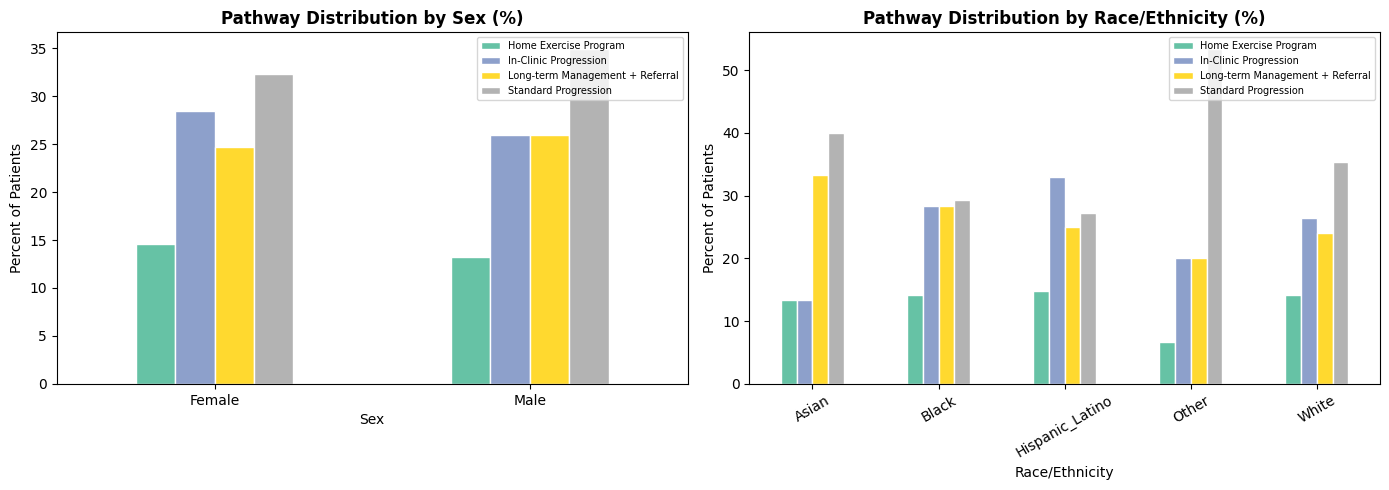

In [21]:
# Equity Analysis

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sex_pathway = pd.crosstab(
    patients["sex"],
    patients["recommended_pathway"],
    normalize="index"
) * 100
sex_pathway.plot(kind="bar", ax=axes[0], colormap="Set2", edgecolor="white")
axes[0].set_title("Pathway Distribution by Sex (%)", fontweight="bold")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Percent of Patients")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(loc="upper right", fontsize=7)

race_pathway = pd.crosstab(
    patients["race_ethnicity"],
    patients["recommended_pathway"],
    normalize="index"
) * 100
race_pathway.plot(kind="bar", ax=axes[1], colormap="Set2", edgecolor="white")
axes[1].set_title("Pathway Distribution by Race/Ethnicity (%)", fontweight="bold")
axes[1].set_xlabel("Race/Ethnicity")
axes[1].set_ylabel("Percent of Patients")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(loc="upper right", fontsize=7)

plt.tight_layout()
plt.savefig("equity_analysis.png", dpi=150, bbox_inches="tight")
plt.show()